# Chapter 10: Recommender Systems Using Restricted Boltzmann Machines

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Build **collaborative filtering** recommenders on a MovieLens-style rating matrix — baselines, **matrix factorization**, and a simplified **RBM (Restricted Boltzmann Machine)** with TensorFlow/Keras.

---

## What you will learn

1. What **recommender systems** and **collaborative filtering** are
2. Prepare a sparse user–item **rating matrix** (synthetic MovieLens-style or Surprise library subset)
3. **Baseline predictors:** global mean and user mean
4. **Matrix factorization** with truncated SVD (Singular Value Decomposition) — 1, 3, and 5 latent factors
5. **RBM-style** neural recommender with Keras — binary ratings, embedding visible units, few epochs
6. Compare **RMSE (Root Mean Squared Error)** and **MAE (Mean Absolute Error)** on held-out test ratings


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | RMSE/MAE comparison chart |
| **scikit-learn (Scientific Kit for Learning)** | TruncatedSVD matrix factorization |
| **TensorFlow / Keras** | RBM-style neural network training |
| **Surprise** *(optional)* | MovieLens-style CF datasets — `pip install scikit-surprise` |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/TensorFlow warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import train/test split for rating holdout
from sklearn.model_selection import train_test_split

# Import TruncatedSVD (Singular Value Decomposition) for matrix factorization baseline
from sklearn.decomposition import TruncatedSVD

# Import mean_squared_error for RMSE (Root Mean Squared Error) calculation
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import TensorFlow (TF) and Keras for RBM-style neural recommender
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Try Surprise library for real MovieLens-style CF data (optional)
try:

    from surprise import Dataset, Reader

    SURPRISE_AVAILABLE = True

except ImportError:

    SURPRISE_AVAILABLE = False

    print("Note: scikit-surprise not installed — using synthetic MovieLens-style ratings.")

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print(f"TensorFlow version: {tf.__version__}")

print("Libraries loaded successfully.")


Note: scikit-surprise not installed — using synthetic MovieLens-style ratings.
TensorFlow version: 2.21.0
Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Rating arrays, latent factors, metrics |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Long-format ratings, result tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | Compare RMSE/MAE across models |
| **sklearn.decomposition.TruncatedSVD** | Low-rank matrix approximation | Matrix factorization with k latent factors |
| **sklearn.metrics** | MSE, MAE | Evaluate rating predictions |
| **TensorFlow / Keras** | Deep learning API | Train simplified RBM-style recommender |
| **Surprise** *(optional)* | CF datasets and algorithms | Load small MovieLens subset if available |


---

## Algorithms Used in This Notebook

### 1. Global mean baseline
- **Prediction:** Every missing rating ≈ average of all known training ratings
- **Purpose:** Simplest benchmark for collaborative filtering

### 2. User mean baseline
- **Prediction:** Rating ≈ that user's average (fallback to global mean for cold users)
- **Purpose:** Captures user bias (some users rate higher than others)

### 3. Matrix factorization — TruncatedSVD
- **Type:** Linear latent-factor model (accessible stand-in for book's explicit MF)
- **Latent factors:** k ∈ {1, 3, 5} — low-rank structure in user–item matrix
- **Idea:** Approximate centered rating matrix as product of user and item factors

### 4. RBM-style recommender (Keras)
- **Type:** Two-layer **Restricted Boltzmann Machine**-inspired network
- **Visible units:** User and item **embeddings** (compact stand-in for one-hot user+item)
- **Hidden units:** Sigmoid layer learns interaction patterns
- **Target:** Binary rating (liked = rating ≥ threshold) with binary cross-entropy

### Evaluation note

We hold out **20% of known ratings** for testing. RMSE and MAE measure how close predicted star ratings are to true held-out values.


---

## 1. What Are Recommender Systems?

**Recommender systems** predict user preferences for items they have not rated yet.

| Concept | Meaning |
|---------|--------|
| **Collaborative filtering (CF)** | Use patterns across users and items — "users like you also liked…" |
| **Rating matrix** | Rows = users, columns = items, entries = star ratings (mostly empty) |
| **Latent factors** | Hidden dimensions explaining taste (genre, mood, complexity) |
| **RBM (Restricted Boltzmann Machine)** | Stochastic neural network with visible + hidden units; book uses it for CF |

**Netflix Prize** (circa 2006–2009) popularized matrix factorization for movie recommendations.


---

## 2. MovieLens-Style Rating Data

The book uses the **MovieLens** dataset. We try **Surprise** built-in data first; otherwise we generate a **synthetic** sparse matrix (~500 users × ~200 items, ~5% density) from latent taste factors.


In [2]:
# Set random seed so ratings and models are reproducible
RANDOM_STATE = 2018

rng = np.random.RandomState(RANDOM_STATE)

# Target matrix size when generating synthetic data
N_USERS = 500

N_ITEMS = 200

# Rating scale (1–5 stars, like MovieLens)
RATING_MIN = 1

RATING_MAX = 5

DATA_SOURCE = "synthetic MovieLens-style"

if SURPRISE_AVAILABLE:

    try:

        # Load built-in ml-100k subset via Surprise — small real CF benchmark
        data = Dataset.load_builtin("ml-100k")

        df_raw = pd.DataFrame(data.raw_ratings, columns=["user_id", "item_id", "rating", "timestamp"])

        # Keep a manageable subset for fast notebook execution
        user_counts = df_raw["user_id"].value_counts()

        top_users = user_counts.head(500).index.tolist()

        item_counts = df_raw["item_id"].value_counts()

        top_items = item_counts.head(200).index.tolist()

        df_ratings = df_raw[df_raw["user_id"].isin(top_users) & df_raw["item_id"].isin(top_items)].copy()

        # Re-index users and items to 0..N-1 for matrix operations
        user_map = {u: i for i, u in enumerate(sorted(df_ratings["user_id"].unique()))}

        item_map = {it: i for i, it in enumerate(sorted(df_ratings["item_id"].unique()))}

        df_ratings["user_idx"] = df_ratings["user_id"].map(user_map)

        df_ratings["item_idx"] = df_ratings["item_id"].map(item_map)

        N_USERS = df_ratings["user_idx"].nunique()

        N_ITEMS = df_ratings["item_idx"].nunique()

        ratings_df = df_ratings[["user_idx", "item_idx", "rating"]].rename(
            columns={"user_idx": "user", "item_idx": "item"}
        )

        DATA_SOURCE = "Surprise ml-100k subset"

    except Exception as e:

        print(f"Surprise load failed ({e}) — falling back to synthetic data.")

        SURPRISE_AVAILABLE = False

if not SURPRISE_AVAILABLE or DATA_SOURCE == "synthetic MovieLens-style":

    # Generate latent factors and sparse ratings (collaborative filtering toy data)
    n_latent = 5

    user_factors = rng.normal(scale=0.8, size=(N_USERS, n_latent))

    item_factors = rng.normal(scale=0.8, size=(N_ITEMS, n_latent))

    user_bias = rng.normal(scale=0.3, size=N_USERS)

    item_bias = rng.normal(scale=0.3, size=N_ITEMS)

    global_bias = 3.2

    n_ratings = int(N_USERS * N_ITEMS * 0.05)

    users = rng.randint(0, N_USERS, size=n_ratings)

    items = rng.randint(0, N_ITEMS, size=n_ratings)

    pairs = set(zip(users.tolist(), items.tolist()))

    while len(pairs) < n_ratings:

        pairs.add((int(rng.randint(N_USERS)), int(rng.randint(N_ITEMS))))

    rows = []

    for u, i in pairs:

        score = global_bias + user_bias[u] + item_bias[i] + np.dot(user_factors[u], item_factors[i])

        score += rng.normal(scale=0.4)

        rating = int(np.clip(np.round(score), RATING_MIN, RATING_MAX))

        rows.append({"user": u, "item": i, "rating": rating})

    ratings_df = pd.DataFrame(rows)

    DATA_SOURCE = "synthetic MovieLens-style"

print(f"Data source: {DATA_SOURCE}")

print(f"Users: {N_USERS}  |  Items: {N_ITEMS}  |  Known ratings: {len(ratings_df)}")

print(f"Sparsity: {1 - len(ratings_df) / (N_USERS * N_ITEMS):.1%} empty cells")

display(ratings_df.head())


Data source: synthetic MovieLens-style
Users: 500  |  Items: 200  |  Known ratings: 5000
Sparsity: 95.0% empty cells


,user,item,rating
0,250,31,4
1,315,160,5
2,227,47,5
3,268,48,1
4,53,160,2


In [3]:
# Split known ratings into train and test (80/20) — test used for evaluation only
train_df, test_df = train_test_split(
    ratings_df, test_size=0.2, random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

# Build dense rating matrix with NaN for missing entries (train only in cells)
R_train = np.full((N_USERS, N_ITEMS), np.nan)

for _, row in train_df.iterrows():

    R_train[int(row["user"]), int(row["item"])] = row["rating"]

global_mean = train_df["rating"].mean()

user_means = train_df.groupby("user")["rating"].mean()

print(f"Train ratings: {len(train_df)}  |  Test ratings: {len(test_df)}")

print(f"Global mean rating: {global_mean:.3f}")

print(f"User mean range: {user_means.min():.2f} – {user_means.max():.2f}")


Train ratings: 4000  |  Test ratings: 1000


Global mean rating: 3.171
User mean range: 1.00 – 5.00


---

## 3. Helper Functions — RMSE and MAE


In [4]:
# Define RMSE (Root Mean Squared Error) from rating pairs
def rmse(y_true, y_pred):

    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# Define MAE (Mean Absolute Error) from rating pairs
def mae(y_true, y_pred):

    return float(mean_absolute_error(y_true, y_pred))


# Predict on test_df using a function(user, item) -> rating
def evaluate_predictor(name, predict_fn, test_frame):

    y_true = test_frame["rating"].values

    y_pred = np.array([predict_fn(int(u), int(i)) for u, i in zip(test_frame["user"], test_frame["item"])])

    return {"Model": name, "RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred)}


---

## 4. Baseline Experiments

### 4.1 Global mean

Predict every test rating as the **average training rating**.


In [5]:
# Global mean baseline — constant prediction
def predict_global_mean(user, item):

    return global_mean

result_global = evaluate_predictor("Global mean", predict_global_mean, test_df)

print(f"Global mean — RMSE: {result_global['RMSE']:.4f}  |  MAE: {result_global['MAE']:.4f}")


Global mean — RMSE: 1.2426  |  MAE: 1.0311


### 4.2 User mean

Predict each rating as that **user's average**; unknown users fall back to global mean.


In [6]:
# User mean baseline — per-user bias
def predict_user_mean(user, item):

    if user in user_means.index:

        return user_means[user]

    return global_mean

result_user = evaluate_predictor("User mean", predict_user_mean, test_df)

print(f"User mean — RMSE: {result_user['RMSE']:.4f}  |  MAE: {result_user['MAE']:.4f}")


User mean — RMSE: 1.2779  |  MAE: 1.0450


---

## 5. Matrix Factorization — Latent Factors (1, 3, 5)

We **center** the imputed rating matrix (missing → global mean), apply **TruncatedSVD**, and reconstruct low-rank predictions.

This mirrors the book's experiments with **1, 3, and 5 latent factors**.


In [7]:
# Impute missing entries with global mean for SVD (Singular Value Decomposition) input
R_imputed = np.where(np.isnan(R_train), global_mean, R_train)

R_centered = R_imputed - global_mean

mf_results = []

mf_models = {}

for n_factors in [1, 3, 5]:

    # Fit TruncatedSVD with n_factors latent dimensions
    svd = TruncatedSVD(n_components=n_factors, random_state=RANDOM_STATE)

    user_latent = svd.fit_transform(R_centered)

    item_latent = svd.components_.T

    mf_models[n_factors] = (user_latent, item_latent)

    def make_predictor(ul, il):

        def predict_mf(user, item):

            pred = global_mean + np.dot(ul[user], il[item])

            return float(np.clip(pred, RATING_MIN, RATING_MAX))

        return predict_mf

    predict_mf_fn = make_predictor(user_latent, item_latent)

    res = evaluate_predictor(f"Matrix factorization (k={n_factors})", predict_mf_fn, test_df)

    mf_results.append(res)

    print(f"MF k={n_factors} — RMSE: {res['RMSE']:.4f}  |  MAE: {res['MAE']:.4f}")


MF k=1 — RMSE: 1.2357  |  MAE: 1.0249
MF k=3 — RMSE: 1.2283  |  MAE: 1.0188
MF k=5 — RMSE: 1.2200  |  MAE: 1.0121


---

## 6. RBM-Style Recommender with TensorFlow/Keras

The book builds a full **RBM class**. Here we use a **simplified** two-layer network that captures the same idea:

| RBM concept | Our Keras implementation |
|-------------|-------------------------|
| Visible units | User + item **Embedding** layers (compact vs one-hot) |
| Hidden units | `Dense(32, activation='sigmoid')` |
| Binary ratings | `rating >= 4` → liked (1), else 0 |
| Training | Few epochs, small batch — fast demo |

For **RMSE/MAE comparison**, we map predicted probability back to a 1–5 star scale.


In [8]:
# Threshold for binary liked / not-liked target (MovieLens-style implicit preference)
BINARY_THRESHOLD = 4

# Prepare training arrays for Keras RBM-style model
train_users = train_df["user"].values.astype(np.int32)

train_items = train_df["item"].values.astype(np.int32)

train_binary = (train_df["rating"].values >= BINARY_THRESHOLD).astype(np.float32)

test_users = test_df["user"].values.astype(np.int32)

test_items = test_df["item"].values.astype(np.int32)

# Embedding size for visible user/item units
EMBED_DIM = 16

HIDDEN_UNITS = 32

# Build RBM-style model: embeddings -> hidden sigmoid -> binary output
user_in = keras.Input(shape=(1,), name="user_id")

item_in = keras.Input(shape=(1,), name="item_id")

user_vec = layers.Embedding(N_USERS, EMBED_DIM, name="user_embedding")(user_in)

item_vec = layers.Embedding(N_ITEMS, EMBED_DIM, name="item_embedding")(item_in)

user_flat = layers.Flatten()(user_vec)

item_flat = layers.Flatten()(item_vec)

visible = layers.Concatenate(name="visible_units")([user_flat, item_flat])

hidden = layers.Dense(HIDDEN_UNITS, activation="sigmoid", name="hidden_units")(visible)

output = layers.Dense(1, activation="sigmoid", name="liked")(hidden)

rbm_model = keras.Model(inputs=[user_in, item_in], outputs=output)

rbm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss="binary_crossentropy")

rbm_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 16)     │      8,000 │ user_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 16)     │      3,200 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ visible_units       │ (None, 32)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_units        │ (None, 32)        │      1,056 │ visible_units[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ liked (Dense)       │ (None, 1)         │         33 │ hidden_units[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train RBM-style recommender for a few epochs (fast demo on small data)
EPOCHS = 5

BATCH_SIZE = 256

history = rbm_model.fit(
    [train_users, train_items],
    train_binary,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_split=0.1,
)


Epoch 1/5


 1/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - loss: 0.7036

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.6801 - val_loss: 0.6742


Epoch 2/5


 1/15 ━━━━━━━━━━━━━━━━━━━━ 5s 361ms/step - loss: 0.6512

...

 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.5722

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5530 - val_loss: 0.7436


Epoch 5/5


 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.5235

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5465 - val_loss: 0.7677


In [10]:
# Batch predict on test set — map binary probability to 1–5 stars for RMSE/MAE
test_probs = rbm_model.predict([test_users, test_items], verbose=0).ravel()

test_star_preds = np.clip(1.0 + test_probs * (RATING_MAX - RATING_MIN), RATING_MIN, RATING_MAX)

y_true_test = test_df["rating"].values

result_rbm = {
    "Model": "RBM-style (Keras embeddings)",
    "RMSE": rmse(y_true_test, test_star_preds),
    "MAE": mae(y_true_test, test_star_preds),
}

print(f"RBM-style — RMSE: {result_rbm['RMSE']:.4f}  |  MAE: {result_rbm['MAE']:.4f}")


RBM-style — RMSE: 1.5768  |  MAE: 1.3091


---

## 7. Compare All Models


Rating prediction comparison on held-out test ratings:


,Model,RMSE,MAE
0,Global mean,1.2426,1.0311
1,User mean,1.2779,1.0450
2,Matrix factorization (k=1),1.2357,1.0249
3,Matrix factorization (k=3),1.2283,1.0188
4,Matrix factorization (k=5),1.2200,1.0121
5,RBM-style (Keras embeddings),1.5768,1.3091


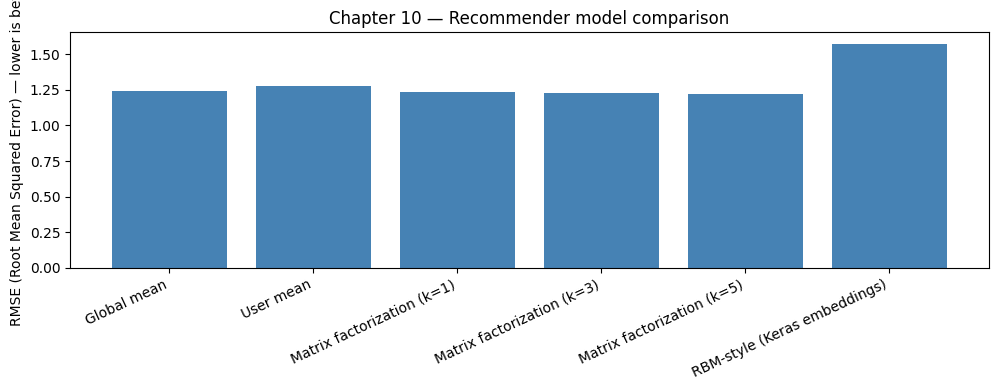

In [11]:
# Combine all results into one comparison table
all_results = [result_global, result_user] + mf_results + [result_rbm]

results_df = pd.DataFrame(all_results)

results_df["RMSE"] = results_df["RMSE"].map(lambda x: f"{x:.4f}")

results_df["MAE"] = results_df["MAE"].map(lambda x: f"{x:.4f}")

print("Rating prediction comparison on held-out test ratings:")

display(results_df)

# Plot RMSE bars (convert back to float for chart)
plot_df = pd.DataFrame(all_results)

plt.figure(figsize=(10, 4))

plt.bar(plot_df["Model"], plot_df["RMSE"], color="steelblue")

plt.ylabel("RMSE (Root Mean Squared Error) — lower is better")

plt.title("Chapter 10 — Recommender model comparison")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()

plt.show()


---

## 8. Glossary — All Chapter 10 Terms

| Term | One-line definition |
|------|---------------------|
| **Recommender system** | Predicts user preferences for unseen items |
| **Collaborative filtering (CF)** | Recommend from user–item rating patterns |
| **Rating matrix** | Users × items table with many missing entries |
| **Sparsity** | Fraction of empty cells in the rating matrix |
| **Global mean baseline** | Predict every rating as dataset average |
| **User mean baseline** | Predict from each user's average rating |
| **Matrix factorization (MF)** | Approximate ratings with latent user/item factors |
| **Latent factor** | Hidden dimension capturing taste or item property |
| **TruncatedSVD** | Low-rank SVD (Singular Value Decomposition) for dense approximations |
| **RMSE (Root Mean Squared Error)** | Square-root of average squared prediction error |
| **MAE (Mean Absolute Error)** | Average absolute prediction error |
| **RBM (Restricted Boltzmann Machine)** | Two-layer stochastic network — visible + hidden units |
| **Visible units** | Input layer representing user–item configuration |
| **Hidden units** | Latent layer learning interaction features |
| **Binary cross-entropy** | Loss for liked / not-liked classification |
| **MovieLens** | Standard movie rating benchmark dataset |


---

## 9. Chapter 10 Summary

```
Recommender systems (Chapter 10) — MovieLens-style ratings
├── Prepare sparse user–item ratings (Surprise or synthetic)
├── Baselines → global mean, user mean
├── Matrix factorization → TruncatedSVD with k = 1, 3, 5
├── RBM-style Keras model → embeddings + hidden sigmoid layer
└── Compare RMSE / MAE on held-out test ratings

Lower RMSE = better star-rating predictions
```

### What's next?

**Chapter 11** stacks RBMs into **DBNs (Deep Belief Networks)** for hierarchical feature detection.

---

### Practice questions

1. Why is the rating matrix **sparse**, and why does that make CF challenging?
2. When would **user mean** beat **global mean**? When would it fail?
3. What does increasing latent factors from 1 → 5 change in matrix factorization?
4. Why does the RBM-style model use **binary** targets but we report RMSE on 1–5 stars?
5. How is an **embedding** similar to one-hot user+item visible units in a full RBM?
